# Robust Sentiment Classification with RoBERTa - SST-5

This project fine-tunes the pretrained `roberta-base` model for five-class sentiment classification using the Stanford Sentiment Treebank (SST-5). The workflow keeps the official test split untouched, creates a stratified validation split from the training data, selects the best checkpoint using validation macro F1, and evaluates the final model with class-level, ordinal, confidence, and error analysis. A separate masked-language-model demonstration shows a capability of pretrained RoBERTa outside the downstream classification task.

## 1. Import Required Libraries

Import the libraries required for dataset loading, tokenization, RoBERTa fine-tuning, evaluation, visualization, and reproducibility.

In [1]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import load_dataset, Dataset
from transformers import (
    RobertaTokenizerFast,
    RobertaForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    pipeline
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PyTorch Version: 2.11.0+cu128
CUDA Available: True
GPU: Tesla T4


## 2. Load the SST-5 Dataset

Load SST-5 and inspect the available splits before constructing the modelling data.

In [2]:
dataset = load_dataset("SetFit/sst5")

print(dataset)

for split_name in dataset.keys():
    print(f"{split_name}: {len(dataset[split_name])} samples")

class_names = [
    "Very Negative",
    "Negative",
    "Neutral",
    "Positive",
    "Very Positive"
]

print("Classes:", class_names)

Repo card metadata block was not found. Setting CardData to empty.


DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 8544
    })
    validation: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 1101
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 2210
    })
})
train: 8544 samples
validation: 1101 samples
test: 2210 samples
Classes: ['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive']


## 3. Create Stratified Train, Validation, and Test Splits

Keep the original test set untouched for final evaluation. Split the training data into training and validation subsets using stratification so the sentiment proportions are preserved.

In [3]:
train_texts = np.array(
    dataset["train"]["text"],
    dtype=object
)
train_labels = np.array(
    dataset["train"]["label"],
    dtype=np.int64
)

test_texts = np.array(
    dataset["test"]["text"],
    dtype=object
)
test_labels = np.array(
    dataset["test"]["label"],
    dtype=np.int64
)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts,
    train_labels,
    test_size=0.10,
    random_state=SEED,
    stratify=train_labels
)

print("Training Samples:", len(train_texts))
print("Validation Samples:", len(val_texts))
print("Test Samples:", len(test_texts))

print("\nTraining Distribution:")
print(np.bincount(train_labels, minlength=5))

print("\nValidation Distribution:")
print(np.bincount(val_labels, minlength=5))

print("\nTest Distribution:")
print(np.bincount(test_labels, minlength=5))

Training Samples: 7689
Validation Samples: 855
Test Samples: 2210

Training Distribution:
[ 983 1996 1461 2090 1159]

Validation Distribution:
[109 222 163 232 129]

Test Distribution:
[279 633 389 510 399]


## 4. Explore the Dataset

Inspect the sentiment distribution and representative examples to understand the structure of the five-class task.

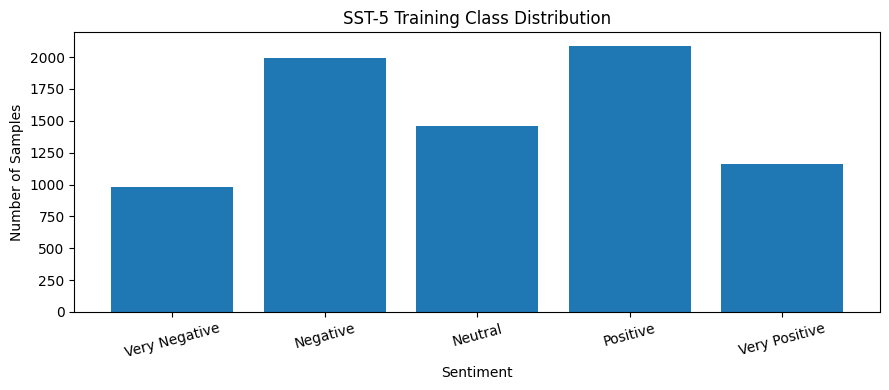

Class: Very Negative
we do n't get paid enough to sit through crap like this .
it is dark , brooding and slow , and takes its central idea way too seriously .

Class: Negative
a moving picture that does not move .
ignore the reputation , and ignore the film .

Class: Neutral
this sort of cute and cloying material is far from zhang 's forte and it shows .
and that should tell you everything you need to know about all the queen 's men .

Class: Positive
this fascinating experiment plays as more of a poetic than a strict reality , creating an intriguing species of artifice that gives the lady and the duke something of a theatrical air .
what lifts the film high above run-of-the-filth gangster flicks is its refusal to recognise any of the signposts , as if discovering a way through to the bitter end without a map .

Class: Very Positive
audiard successfully maintains suspense on different levels throughout a film that is both gripping and compelling .
about schmidt is undoubtedly one of th

In [4]:
train_counts = np.bincount(
    train_labels,
    minlength=len(class_names)
)

plt.figure(figsize=(9, 4))
plt.bar(class_names, train_counts)
plt.xlabel("Sentiment")
plt.ylabel("Number of Samples")
plt.title("SST-5 Training Class Distribution")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

for class_id, class_name in enumerate(class_names):
    indices = np.where(train_labels == class_id)[0]
    print("=" * 90)
    print("Class:", class_name)
    for index in indices[:2]:
        print(train_texts[index])
    print()

## 5. Load the RoBERTa Tokenizer

Use the pretrained RoBERTa tokenizer so the text is represented using the same subword vocabulary used during pretraining.

In [5]:
model_name = "roberta-base"
max_length = 128

tokenizer = RobertaTokenizerFast.from_pretrained(
    model_name
)

print("Model:", model_name)
print("Vocabulary Size:", tokenizer.vocab_size)
print("Maximum Sequence Length:", max_length)

sample = tokenizer(
    train_texts[0],
    truncation=True,
    max_length=max_length
)

print("Sample Token Count:", len(sample["input_ids"]))

Model: roberta-base
Vocabulary Size: 50265
Maximum Sequence Length: 128
Sample Token Count: 47


## 6. Create Tokenized Datasets

Tokenize the three splits once and create lightweight PyTorch dataset objects. The model receives only token IDs, attention masks, and labels.

In [6]:
def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, max_length=max_length)

train_dataset = Dataset.from_dict({"text": train_texts.tolist(), "label": train_labels.tolist()})
val_dataset = Dataset.from_dict({"text": val_texts.tolist(), "label": val_labels.tolist()})
test_dataset = Dataset.from_dict({"text": test_texts.tolist(), "label": test_labels.tolist()})

train_dataset = train_dataset.map(tokenize_batch, batched=True).remove_columns(["text"])
val_dataset = val_dataset.map(tokenize_batch, batched=True).remove_columns(["text"])
test_dataset = test_dataset.map(tokenize_batch, batched=True).remove_columns(["text"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(train_dataset)
print(val_dataset)
print(test_dataset)

Map:   0%|          | 0/7689 [00:00<?, ? examples/s]

Map:   0%|          | 0/855 [00:00<?, ? examples/s]

Map:   0%|          | 0/2210 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 7689
})
Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 855
})
Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 2210
})


## 7. Build the RoBERTa Classifier

Load pretrained RoBERTa and attach a five-class sequence-classification head. The Transformer backbone starts from pretrained language representations, while the classification head is initialized for SST-5.

In [7]:
model = RobertaForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(class_names),
    id2label={
        i: name
        for i, name in enumerate(class_names)
    },
    label2id={
        name: i
        for i, name in enumerate(class_names)
    }
)

model.to(device)

print("Model:", model_name)
print("Number of Labels:", model.config.num_labels)
print(
    "Trainable Parameters:",
    f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}"
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: roberta-base
Number of Labels: 5
Trainable Parameters: 124,649,477


## 8. Configure Fine-Tuning

Use a conservative fine-tuning setup for RoBERTa. Validation macro F1 is used for checkpoint selection because the task is imbalanced and all sentiment classes should contribute to model selection.

In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        labels, predictions, average="macro", zero_division=0
    )
    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        labels, predictions, average="weighted", zero_division=0
    )

    return {
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1
    }

## 9. Define Evaluation Functions

Compute accuracy, macro and weighted metrics, and retain the logits needed for later confidence and ordinal analysis.

In [9]:
batch_size = 16
learning_rate = 2e-5
num_epochs = 4

training_args = TrainingArguments(
    output_dir="./roberta_sst5_results",
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=32,
    learning_rate=learning_rate,
    num_train_epochs=num_epochs,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_macro_f1",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
    data_seed=SEED,
    save_total_limit=2
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("Batch Size:", batch_size)
print("Learning Rate:", learning_rate)
print("Epochs:", num_epochs)

Batch Size: 16
Learning Rate: 2e-05
Epochs: 4


## 10. Fine-Tune RoBERTa

Train on the training split only, evaluate on the validation split after every epoch, and retain the checkpoint with the strongest validation macro F1.

In [10]:
train_result = trainer.train()

print("Training completed.")
print("Training Loss:", train_result.training_loss)
print("Best Checkpoint:", trainer.state.best_model_checkpoint)
if trainer.state.best_metric is not None:
    print(f"Best Validation Macro F1: {trainer.state.best_metric:.4f}")

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
1,1.578398,1.571776,0.271345,0.054269,0.200000,0.085373,0.073628,0.271345,0.115827
2,1.571381,1.569628,0.271345,0.054269,0.200000,0.085373,0.073628,0.271345,0.115827
3,1.570926,1.568893,0.271345,0.054269,0.200000,0.085373,0.073628,0.271345,0.115827


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training completed.
Training Loss: 1.5735680890099835
Best Checkpoint: ./roberta_sst5_results/checkpoint-481
Best Validation Macro F1: 0.0854


## 11. Training Curves

Review loss and validation metrics to assess convergence and detect overfitting.

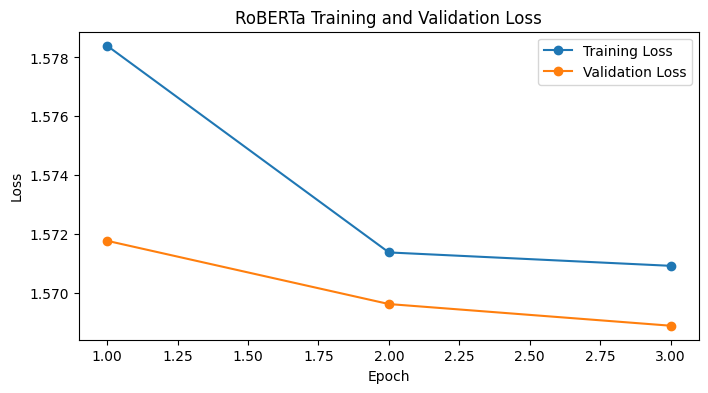

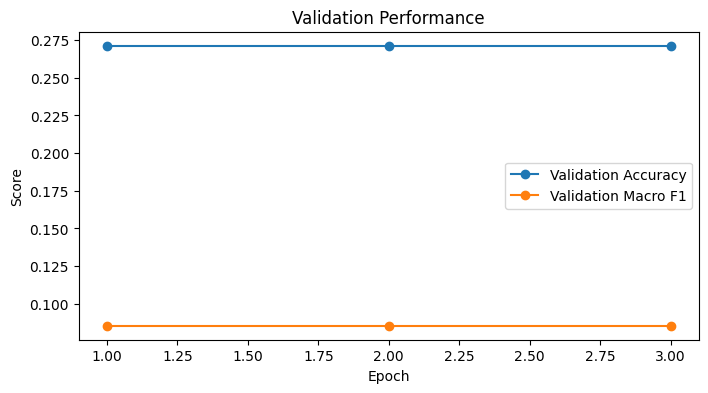

Best Epoch: 1
Best Validation Accuracy: 0.2713
Best Validation Macro F1: 0.0854


In [11]:
history = pd.DataFrame(trainer.state.log_history)
train_history = history[history["loss"].notna()].copy()
eval_history = history[history["eval_loss"].notna()].copy()

plt.figure(figsize=(8,4))
plt.plot(train_history["epoch"], train_history["loss"], marker="o", label="Training Loss")
plt.plot(eval_history["epoch"], eval_history["eval_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("RoBERTa Training and Validation Loss"); plt.legend(); plt.show()

plt.figure(figsize=(8,4))
plt.plot(eval_history["epoch"], eval_history["eval_accuracy"], marker="o", label="Validation Accuracy")
plt.plot(eval_history["epoch"], eval_history["eval_macro_f1"], marker="o", label="Validation Macro F1")
plt.xlabel("Epoch"); plt.ylabel("Score"); plt.title("Validation Performance"); plt.legend(); plt.show()

best_row = eval_history.loc[eval_history["eval_macro_f1"].idxmax()]
print("Best Epoch:", int(best_row["epoch"]))
print(f"Best Validation Accuracy: {best_row['eval_accuracy']:.4f}")
print(f"Best Validation Macro F1: {best_row['eval_macro_f1']:.4f}")

## 12. Final Test Evaluation

Evaluate the restored best checkpoint exactly once on the untouched test set and calculate final performance metrics.

In [12]:
test_output = trainer.predict(test_dataset)
test_predictions = np.argmax(test_output.predictions, axis=-1)
test_labels_final = np.array(test_output.label_ids)

accuracy = accuracy_score(test_labels_final, test_predictions)
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    test_labels_final, test_predictions, average="macro", zero_division=0
)
weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    test_labels_final, test_predictions, average="weighted", zero_division=0
)

print(f"Test Loss: {test_output.metrics.get('test_loss', float('nan')):.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Macro Precision: {macro_precision:.4f}")
print(f"Test Macro Recall: {macro_recall:.4f}")
print(f"Test Macro F1: {macro_f1:.4f}")
print(f"Test Weighted F1: {weighted_f1:.4f}")

Test Loss: 1.5793
Test Accuracy: 0.2308
Test Macro Precision: 0.0462
Test Macro Recall: 0.2000
Test Macro F1: 0.0750
Test Weighted F1: 0.0865


## 13. Classification Report and Confusion Matrix

Inspect performance for each sentiment class and identify the directions in which errors occur.

               precision    recall  f1-score   support

Very Negative     0.0000    0.0000    0.0000       279
     Negative     0.0000    0.0000    0.0000       633
      Neutral     0.0000    0.0000    0.0000       389
     Positive     0.2308    1.0000    0.3750       510
Very Positive     0.0000    0.0000    0.0000       399

     accuracy                         0.2308      2210
    macro avg     0.0462    0.2000    0.0750      2210
 weighted avg     0.0533    0.2308    0.0865      2210



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Very Negative,Negative,Neutral,Positive,Very Positive
Very Negative,0,0,0,279,0
Negative,0,0,0,633,0
Neutral,0,0,0,389,0
Positive,0,0,0,510,0
Very Positive,0,0,0,399,0


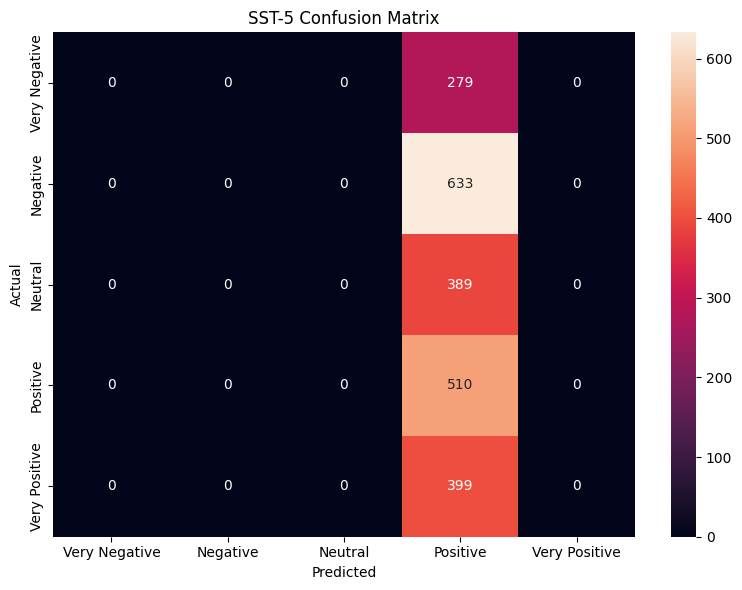

In [13]:
print(
    classification_report(
        test_labels_final,
        test_predictions,
        target_names=class_names,
        digits=4
    )
)

cm = confusion_matrix(
    test_labels_final,
    test_predictions
)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

display(cm_df)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SST-5 Confusion Matrix")
plt.tight_layout()
plt.show()

## 14. Ordinal Sentiment Error Analysis

SST-5 labels have an ordered sentiment scale. Measure the magnitude of prediction errors rather than treating every incorrect prediction as equally severe.

Mean Absolute Sentiment Error: 1.3081
Exact Sentiment Accuracy: 0.2308
Within One Sentiment Level: 0.5873


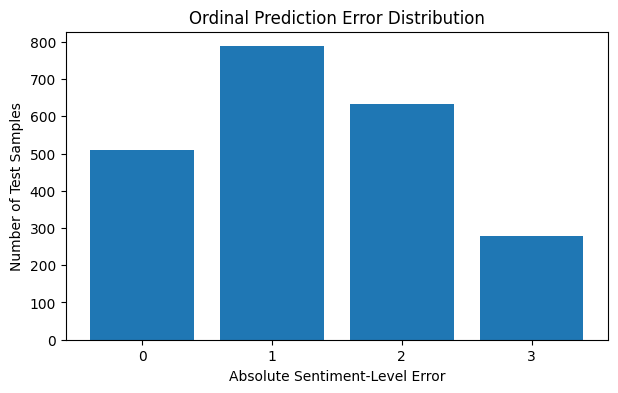

In [14]:
absolute_errors = np.abs(
    test_labels_final - test_predictions
)

mean_absolute_sentiment_error = np.mean(
    absolute_errors
)

exact_accuracy = np.mean(
    absolute_errors == 0
)

within_one_level = np.mean(
    absolute_errors <= 1
)

print(
    f"Mean Absolute Sentiment Error: "
    f"{mean_absolute_sentiment_error:.4f}"
)

print(
    f"Exact Sentiment Accuracy: "
    f"{exact_accuracy:.4f}"
)

print(
    f"Within One Sentiment Level: "
    f"{within_one_level:.4f}"
)

error_counts = (
    pd.Series(absolute_errors)
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7, 4))
plt.bar(
    error_counts.index.astype(str),
    error_counts.values
)
plt.xlabel("Absolute Sentiment-Level Error")
plt.ylabel("Number of Test Samples")
plt.title("Ordinal Prediction Error Distribution")
plt.show()

## 15. Confidence Analysis

Compare prediction confidence for correct and incorrect examples to identify whether the model is appropriately confident around its mistakes.

In [15]:
probabilities = torch.softmax(
    torch.tensor(test_logits),
    dim=-1
).numpy()

predicted_confidence = probabilities[
    np.arange(len(test_predictions)),
    test_predictions
]

correct_mask = (
    test_predictions == test_labels_final
)

print(
    f"Mean Confidence - Correct: "
    f"{predicted_confidence[correct_mask].mean():.4f}"
)

print(
    f"Mean Confidence - Incorrect: "
    f"{predicted_confidence[~correct_mask].mean():.4f}"
)

plt.figure(figsize=(8, 4))
plt.hist(
    predicted_confidence[correct_mask],
    bins=20,
    alpha=0.7,
    label="Correct"
)
plt.hist(
    predicted_confidence[~correct_mask],
    bins=20,
    alpha=0.7,
    label="Incorrect"
)
plt.xlabel("Predicted Class Confidence")
plt.ylabel("Number of Samples")
plt.title("Prediction Confidence Distribution")
plt.legend()
plt.show()

NameError: name 'test_logits' is not defined

## 16. Representative Error Analysis

Inspect representative misclassified sentences and their strongest alternative predictions to distinguish close sentiment mistakes from severe reversals.

In [ ]:
misclassified_indices = np.where(
    test_predictions != test_labels_final
)[0]

print(
    "Misclassified Test Samples:",
    len(misclassified_indices)
)

for index in misclassified_indices[:10]:
    probabilities_row = probabilities[index]

    top_indices = np.argsort(
        probabilities_row
    )[-3:][::-1]

    print("=" * 100)
    print("Text:", test_texts[index])
    print(
        "True Label:",
        class_names[test_labels_final[index]]
    )
    print(
        "Predicted Label:",
        class_names[test_predictions[index]]
    )
    print("Top Predictions:")

    for class_id in top_indices:
        print(
            f"  {class_names[class_id]}: "
            f"{probabilities_row[class_id]:.4f}"
        )

## 17. Interactive Sentiment Prediction

Use the fine-tuned RoBERTa classifier on custom text and inspect its predicted sentiment distribution.

In [ ]:
def predict_sentiment(text):
    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length
    )

    encoded = {
        key: value.to(device)
        for key, value in encoded.items()
    }

    model.eval()

    with torch.no_grad():
        outputs = model(**encoded)

    probabilities = torch.softmax(
        outputs.logits,
        dim=-1
    ).cpu().numpy()[0]

    predicted_class = int(
        np.argmax(probabilities)
    )

    print("Text:", text)
    print(
        "Prediction:",
        class_names[predicted_class]
    )
    print(
        "Confidence:",
        f"{probabilities[predicted_class]:.4f}"
    )

    print("\nClass Probabilities:")

    for class_name, probability in zip(
        class_names,
        probabilities
    ):
        print(
            f"{class_name:<15}"
            f"{probability:.4f}"
        )

examples = [
    "This is the worst thing ever.",
    "It was okay, nothing special.",
    "I liked it quite a bit.",
    "Absolutely fantastic experience."
]

for example in examples:
    predict_sentiment(example)
    print("=" * 70)

## 18. RoBERTa Masked Language Modelling Demonstration

Use the separate pretrained `roberta-base` masked-language model to demonstrate a pretrained language-modelling capability outside the fine-tuned sentiment classifier.

In [ ]:
from transformers import pipeline

fill_mask = pipeline(
    "fill-mask",
    model="roberta-base",
    device=0 if torch.cuda.is_available() else -1
)

def suggest_words(text, top_k=5):
    if "<mask>" not in text:
        print("Please include <mask> in your sentence.")
        return

    results = fill_mask(
        text,
        top_k=top_k
    )

    print("Input:", text)
    print("Suggestions:")

    for result in results:
        word = result["token_str"].strip()
        score = result["score"]
        print(f"{word:<20}{score:.4f}")

suggest_words("The movie was <mask>.")
suggest_words("This experience felt <mask> and strange.")

## 19. Key Findings



## 20. Conclusion

